Aprendizado de variedades (Manifold Learning) com fluxo de clusterização distribuída por tipo de característica é mais informativo do que o UMAP para conjuntos de dados clínicos tabulares

Importando as Libraries

In [51]:
import sys
import os

# Ajusta o caminho para encontrar os módulos do FDC
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Diretório atual: {current_dir}")
print(f"Diretório pai adicionado: {parent_dir}")

Diretório atual: c:\Católica\IA\Clinical-database\FDC_Low_Dimension\Jupyter Notebooks
Diretório pai adicionado: c:\Católica\IA\Clinical-database\FDC_Low_Dimension


In [52]:
import subprocess
import sys, os
sys.path.insert(0, os.path.abspath('../../FDC_Intermediate_Dimension'))

# Instala pacotes necessários que podem estar faltando
packages_to_install = ['yellowbrick']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} já está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado com sucesso")

✓ yellowbrick já está instalado


In [53]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
import math
import umap.umap_ as umap
%config InlineBackend.figure_format = 'svg'

In [54]:
from cluster_val import *

Importando os dados

In [55]:
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
data_with_target=pd.read_csv('../Datasets/survey lung cancer.csv')

Pré-processamento dos dados

In [56]:
data_with_target.isna().sum() #Detecta valores faltando por coluna

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [57]:
#Transforma variável categórica (F/M) em numérica (1/0) -> label encoding manual
gender_mod= {'GENDER': {'F':1,'M':0}}
data_with_target.replace(gender_mod,inplace=True)
data_with_target['GENDER']

0      0
1      0
2      1
3      0
4      1
      ..
304    1
305    0
306    0
307    0
308    0
Name: GENDER, Length: 309, dtype: int64

In [58]:
np.random.seed(42)
data_with_target=data_with_target.sample(frac=1) #Embaralha o dataset
np.random.seed(42)
i=[x for x in range(309)]

data_with_target.set_index(pd.Series(i), inplace=True)

In [59]:
data_with_target['LUNG_CANCER']

0      YES
1      YES
2      YES
3      YES
4      YES
      ... 
304    YES
305    YES
306    YES
307     NO
308    YES
Name: LUNG_CANCER, Length: 309, dtype: object

In [60]:
data=data_with_target.drop(['LUNG_CANCER'],axis=1)

In [61]:
data.shape

(309, 15)

UMAP nos dados originais

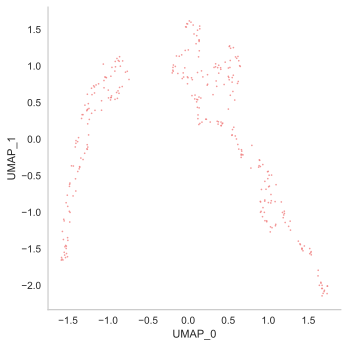

In [62]:
from fdc.fdc import feature_clustering

umap_emb=feature_clustering(15,0.1,'euclidean',data,True)

ANOVA test, Silhouette_score e Dunn index para clusters UMAP extraidos usando k-means

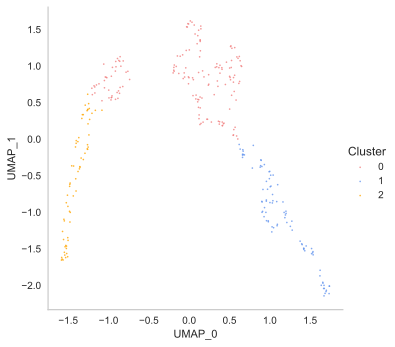

In [63]:
from fdc.clustering import Clustering

umap_clustering=Clustering(umap_emb,umap_emb,True)
umap_cluster_list,umap_cluster_counts=umap_clustering.K_means(3)

In [64]:
cont_list=['AGE']

ord_list=['SMOKING','GENDER','CHRONIC DISEASE','ALCOHOL CONSUMING','SHORTNESS OF BREATH']

nom_list=['YELLOW_FINGERS','ANXIETY','PEER_PRESSURE','WHEEZING','COUGHING','SWALLOWING DIFFICULTY','CHEST PAIN','FATIGUE ','ALLERGY ']

In [65]:
### ANOVA TEST

data['Cluster']=umap_cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  26.67 %
percentage of ordinal features having p-value less than 0.05:  20.0 %
percentage of  nominal features having p-value less than 0.05:  22.22222222222222 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [66]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

In [67]:
silhouette_score(umap_emb, umap_cluster_list, metric='euclidean')

0.6569111550668095

Visualizing Silhouette score (Pode-se escolher o número de clusters baseado no score)

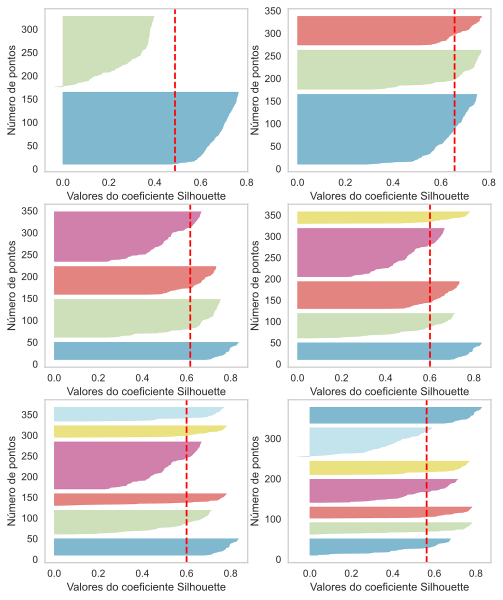

In [68]:
Silhouette_visual(umap_emb)

Elbow plot para o umap_embedding

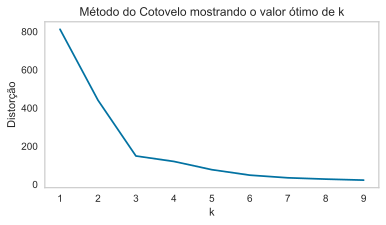

In [69]:
elbow_plot(umap_emb)

In [70]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list))

0.0331734241671445

ANOVA test, Silhouette_score e Dunn index para clusters UMAP extraidos usando clustering Aglomerativo

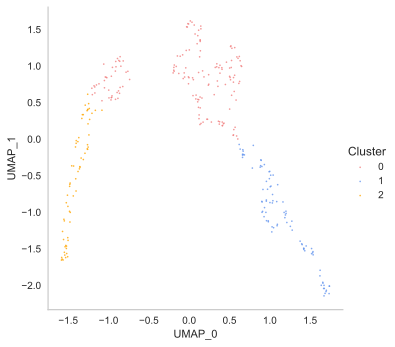

In [71]:
umap_cluster_list_agglo,umap_cluster_counts_agglo=umap_clustering.Agglomerative(3,'euclidean','ward')

In [72]:
### ANOVA TEST

data['Cluster']=umap_cluster_list_agglo
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  26.67 %
percentage of ordinal features having p-value less than 0.05:  20.0 %
percentage of  nominal features having p-value less than 0.05:  22.22222222222222 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [73]:
silhouette_score(umap_emb, umap_cluster_list_agglo, metric='euclidean')

0.6569111550668095

In [74]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_agglo))

0.0331734241671445

ANOVA test, Silhouette_score e Dunn index para clusters UMAP extraidos usando clustering do DBSCAN

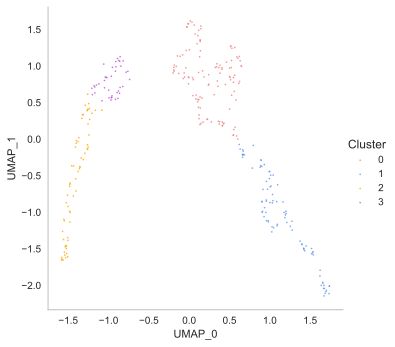

In [75]:
umap_cluster_list_dbscan,umap_cluster_counts_dbscan=umap_clustering.DBSCAN(0.5,20)

In [76]:
### ANOVA TEST

data['Cluster']=umap_cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))-1):
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  26.67 %
percentage of ordinal features having p-value less than 0.05:  20.0 %
percentage of  nominal features having p-value less than 0.05:  22.22222222222222 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [77]:
#Remove os indices considerados ruídos pelo algoritmo
non_noise_indices= np.where(np.array(umap_cluster_list_dbscan)!=-1)
umap_emb= umap_emb.iloc[non_noise_indices]
#FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
umap_cluster_list_dbscan= np.array(umap_cluster_list_dbscan)[non_noise_indices]

In [78]:
silhouette_score(umap_emb, umap_cluster_list_dbscan, metric='euclidean')

0.6689165988372793

In [79]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_dbscan))

0.02491907115608306

Dividindo as variaveis
- cont_list = continuas
- ord_list = ordinais
-  nom_list  = nominais

In [80]:
cont_list=['AGE']

ord_list=['SMOKING','GENDER','CHRONIC DISEASE','ALCOHOL CONSUMING','SHORTNESS OF BREATH']

nom_list=['YELLOW_FINGERS','ANXIETY','PEER_PRESSURE','WHEEZING','COUGHING','SWALLOWING DIFFICULTY','CHEST PAIN','FATIGUE ','ALLERGY ']

In [81]:
len(ord_list)

5

In [82]:
len(nom_list)

9

In [83]:
len(cont_list)

1

Usando FDC nos dados originais

In [84]:
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified

FDC.normalize (init): 0.00000 / 0.000s
FDC.normalize (clustering CONT): 0.64062 / 0.641s
FDC.normalize (clustering ORD): 0.75000 / 1.391s
FDC.normalize (clustering NOM): 0.57812 / 1.969s
FDC.normalize (concat): 0.01562 / 1.984s
FDC.normalize (umap 5 -> 2): 0.25000 / 2.234s
FDC.normalize (array -> DataFrame): 0.00000 / 2.234s


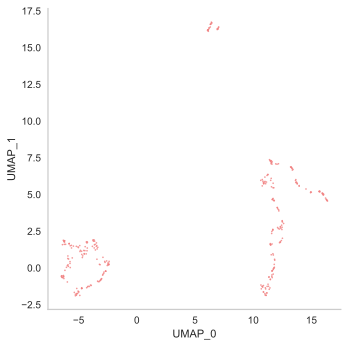

FDC.normalize (plotting): 0.37500 / 2.609s
FDC.normalize (array -> DataFrame): 0.00000 / 2.609s
FDC.normalize (total): 0.00000 / 2.609s


In [85]:
fdc = FDC(clustering_cont=Clustering('euclidean',15,0.1,max_components=1)
          , clustering_ord=Clustering('canberra',15,0.1)
          , clustering_nom=Clustering('hamming',15,0.1)
          , visual=True
          , use_pandas_output=True
          , with_2d_embedding=True
          )

fdc.selectFeatures(continueous=cont_list, nomial=nom_list, ordinal=ord_list)

FDC_emb_high,FDC_emb_low = fdc.normalize(data,n_neighbors=15, min_dist=0.1,cont_list=cont_list, nom_list=nom_list, ord_list=ord_list,
                  with_2d_embedding=True,
                  visual=True)

ANOVA test, Silhouette_score e Dunn index para clusters FDC(Dimensão intermediária) extraidos usando clustering do K-means

In [86]:
from fdc.clustering import Clustering

In [87]:
FDC_emb_low.rename(columns={"UMAP_0": "FDC_0", "UMAP_1": "FDC_1"},inplace=True)

In [88]:
FDC_emb_high_original = FDC_emb_high.copy()
FDC_emb_low_original = FDC_emb_low.copy()
#cópias necessárias

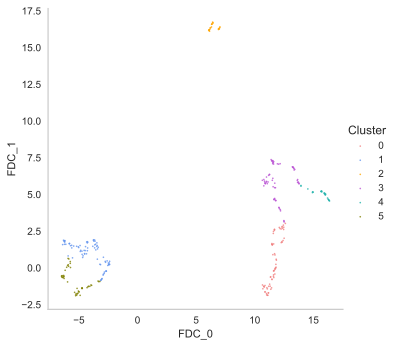

Pacientes perdidos como ruído: 0 de 309
Clusters encontrados: 5


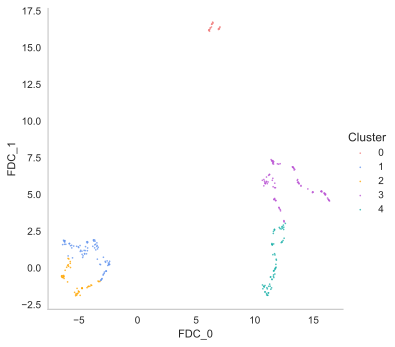

In [89]:
clustering=Clustering(FDC_emb_low,FDC_emb_low,True)
cluster_list,cluster_counts=clustering.K_means(6)
# HDBSCAN - melhoria proposta, resolve o problema de perda de pacientes do DBSCAN
hdbscan_cluster_list, hdbscan_cluster_counts = clustering.HDBSCAN(min_cluster_size=15)

In [90]:
### ANOVA TEST

data['Cluster']=cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  93.33 %
percentage of ordinal features having p-value less than 0.05:  80.0 %
percentage of  nominal features having p-value less than 0.05:  100.0 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [91]:
silhouette_score(FDC_emb_low, cluster_list, metric='euclidean')

0.5401573158897481

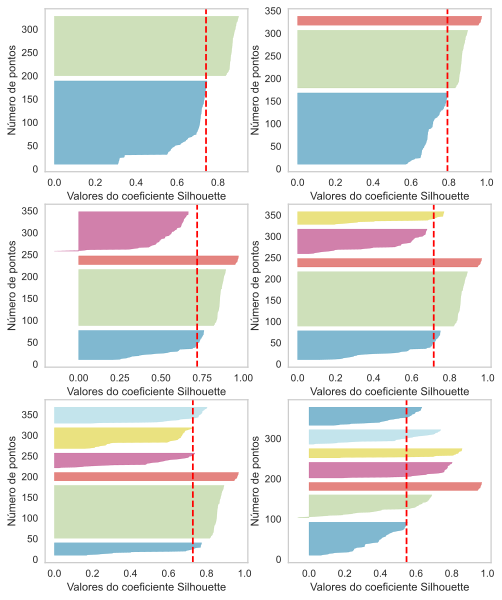

In [92]:
Silhouette_visual(FDC_emb_low)

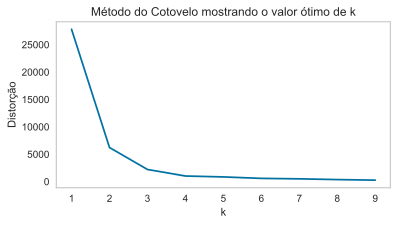

In [93]:
elbow_plot(FDC_emb_low)

In [94]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list))

0.014756849590860831

ANOVA test, Silhouette_score e Dunn index para clusters FDC(Dimensão intermediária) extraidos usando clustering Aglomerativo

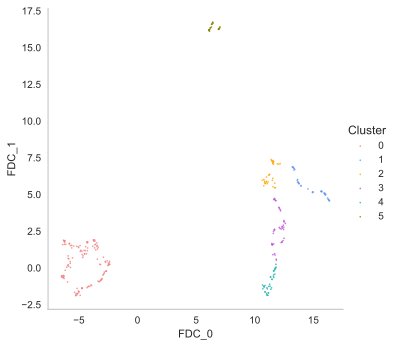

In [95]:
cluster_list_agglo,cluster_counts_agglo=clustering.Agglomerative(6,'euclidean','ward')

In [96]:
### ANOVA TEST

data['Cluster']=cluster_list_agglo
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  93.33 %
percentage of ordinal features having p-value less than 0.05:  80.0 %
percentage of  nominal features having p-value less than 0.05:  100.0 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [97]:
silhouette_score(FDC_emb_low, cluster_list_agglo, metric='euclidean')

0.7355044440088998

In [98]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_agglo))

0.06774001512746393

ANOVA test, Silhouette_score e Dunn index para clusters FDC(Dimensão intermediária) extraidos usando clustering do DBSCAN

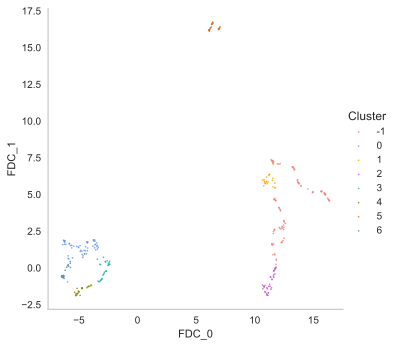

In [99]:
cluster_list_dbscan,cluster_counts_dbscan=clustering.DBSCAN(0.8,20)

In [ ]:
### ANOVA TEST


data['Cluster']=cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))-1):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5,c_6,c_7,c_8)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  93.33 %
percentage of ordinal features having p-value less than 0.05:  80.0 %
percentage of  nominal features having p-value less than 0.05:  100.0 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [101]:
#Remove indices considerados ruídos
non_noise_indices= np.where(np.array(cluster_list_dbscan)!=-1)
FDC_emb_high= FDC_emb_high.iloc[non_noise_indices]
FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
cluster_list_dbscan= np.array(cluster_list_dbscan)[non_noise_indices]

In [102]:
silhouette_score(FDC_emb_low, cluster_list_dbscan, metric='euclidean') #média de separação ponto a ponto

0.791833987688851

In [103]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_dbscan)) #pior caso de separação vs pior dispersão

0.2183848891026854

In [104]:
# 1. Filtra ruído do HDBSCAN para calcular métricas
non_noise_hdbscan = [i for i, x in enumerate(hdbscan_cluster_list) if x != -1]
hdbscan_emb = FDC_emb_low_original.iloc[non_noise_hdbscan]
hdbscan_labels = [hdbscan_cluster_list[i] for i in non_noise_hdbscan]
hdbscan_data = data.iloc[non_noise_hdbscan]

# 2. Filtra ruído do DBSCAN para calcular métricas
non_noise_dbscan = [i for i, x in enumerate(cluster_list_dbscan) if x != -1]
dbscan_emb = FDC_emb_low_original.iloc[non_noise_dbscan]
dbscan_labels = [cluster_list_dbscan[i] for i in non_noise_dbscan]
dbscan_data = data.iloc[non_noise_dbscan]

resultados = {
    'K-means': {
        'Silhouette': round(silhouette_score(FDC_emb_low_original, cluster_list), 3),
        'Dunn': round(dunn_index(cluster_wise_df(pd.DataFrame(FDC_emb_low_original).assign(Cluster=cluster_list), cluster_list)), 3),
        'ANOVA (% features significativas)': calcular_anova(data, cluster_list, cont_list, ord_list),
        'Pacientes perdidos': 0
    },
    'Agglomerative': {
        'Silhouette': round(silhouette_score(FDC_emb_low_original, cluster_list_agglo), 3),
        'Dunn': round(dunn_index(cluster_wise_df(pd.DataFrame(FDC_emb_low_original).assign(Cluster=cluster_list_agglo), cluster_list_agglo)), 3),
        'ANOVA (% features significativas)': calcular_anova(data, cluster_list_agglo, cont_list, ord_list),
        'Pacientes perdidos': 0
    },
    'DBSCAN': {
        'Silhouette': round(silhouette_score(dbscan_emb, dbscan_labels), 3),
        'Dunn': round(dunn_index(cluster_wise_df(pd.DataFrame(dbscan_emb).assign(Cluster=dbscan_labels), dbscan_labels)), 3),
        'ANOVA (% features significativas)': calcular_anova(dbscan_data, dbscan_labels, cont_list, ord_list),
        'Pacientes perdidos': sum(1 for x in cluster_list_dbscan if x == -1)
    },
    'HDBSCAN': {
        'Silhouette': round(silhouette_score(hdbscan_emb, hdbscan_labels), 3),
        'Dunn': round(dunn_index(cluster_wise_df(pd.DataFrame(hdbscan_emb).assign(Cluster=hdbscan_labels), hdbscan_labels)), 3),
        'ANOVA (% features significativas)': calcular_anova(hdbscan_data, hdbscan_labels, cont_list, ord_list),
        'Pacientes perdidos': sum(1 for x in hdbscan_cluster_list if x == -1)
    }
}

pd.DataFrame(resultados).T

,Silhouette,Dunn,ANOVA (% features significativas),Pacientes perdidos
K-means,0.518,0.040,83.33,0.0
Agglomerative,0.718,0.068,83.33,0.0
DBSCAN,-0.188,0.001,0.00,0.0
HDBSCAN,0.516,0.015,83.33,0.0
